# 15. Threshold Tuning for Fraud Detection

This notebook tunes the Random Forest fraud-probability threshold selected for the credit card fraud detection workflow. Notebook `14_model_evaluation.ipynb` showed that Random Forest is the strongest candidate model because it provides better practical fraud-detection performance than Logistic Regression, especially in PR-AUC, F1-score, top-risk ranking, and alert-volume control.


## Threshold Tuning Objective

This notebook tunes fraud probability thresholds for operational use. The focus is not maximum accuracy. The focus is choosing a threshold policy that catches more fraud while keeping false positives acceptable for business operations.

This notebook should:

- use validation/OOF predictions for threshold selection
- keep the final holdout/test set strictly for confirmation
- produce a practical APPROVE / REVIEW / BLOCK policy for notebook `16_decision_logic.ipynb`
- leave notebook `17_final_model_training.ipynb` to honest final reporting only


## Methodology Note: Avoid Tuning on Final Test Set

Threshold tuning must not be done on the final holdout/test set. If the same unseen data is used both to choose and to evaluate thresholds, the result becomes optimistic and less trustworthy.

This notebook follows the safer workflow:

1. Use validation or OOF predictions to compare thresholds and select candidates.
2. Use the final holdout/test set only to confirm whether the chosen validation/OOF policy generalizes.

The final holdout/test set is not used to select thresholds. It is used only to verify whether the selected validation/OOF threshold generalizes to unseen data.


## Load Libraries and Project Paths

The notebook reuses saved Random Forest prediction files from notebook `13_model_training.ipynb`. Thresholds are selected from validation/OOF predictions when available, while holdout/test predictions are reserved for final evaluation of the selected thresholds.

In [1]:
import json
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
)

try:
    from IPython.display import Markdown, display
except ImportError:
    Markdown = str
    display = print

sys.path.append(str(Path("..").resolve()))
from src.config import PROJECT_ROOT

NOTEBOOK_NAME = "15_threshold_tuning"
MODEL_NAME = "Random Forest"
MODEL_NAME_KEY = "random_forest"
TARGET_COLUMN = "Class"

TRAINING_NOTEBOOK_NAME = "13_model_training"
TRAINING_TABLES_DIR = PROJECT_ROOT / "reports" / "tables" / TRAINING_NOTEBOOK_NAME
TRAINING_ARTIFACTS_DIR = PROJECT_ROOT / "artifacts" / TRAINING_NOTEBOOK_NAME

PREDICTIONS_FILE = TRAINING_TABLES_DIR / "baseline_test_predictions.csv"
OOF_PREDICTIONS_FILE = TRAINING_TABLES_DIR / "cv_oof_predictions.csv"
RANDOM_FOREST_ARTIFACT_FILE = TRAINING_ARTIFACTS_DIR / "baseline_random_forest.joblib"
SPLIT_IDS_FILE = TRAINING_ARTIFACTS_DIR / "train_test_split_ids.json"
SELECTED_DATA_FILE = PROJECT_ROOT / "data" / "processed" / "creditcard_selected_features.csv"

CANDIDATE_THRESHOLD_SELECTION_FILES = [
    OOF_PREDICTIONS_FILE,
    TRAINING_TABLES_DIR / "validation_predictions.csv",
    TRAINING_TABLES_DIR / "random_forest_validation_predictions.csv",
    PROJECT_ROOT / "reports" / "tables" / "oof_predictions.csv",
    PROJECT_ROOT / "reports" / "tables" / "validation_predictions.csv",
    PROJECT_ROOT / "reports" / "tables" / "train_oof_predictions.csv",
    PROJECT_ROOT / "reports" / "tables" / "model_validation_predictions.csv",
    PROJECT_ROOT / "reports" / "tables" / "random_forest_validation_predictions.csv",
]

ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
NB_ARTIFACTS_DIR = ARTIFACTS_DIR / NOTEBOOK_NAME
NB_TABLES_DIR = PROJECT_ROOT / "reports" / "tables" / NOTEBOOK_NAME
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures" / NOTEBOOK_NAME

SELECTED_THRESHOLD_FILE = NB_ARTIFACTS_DIR / "selected_threshold.json"
THRESHOLD_EVALUATION_FILE = NB_TABLES_DIR / "threshold_evaluation.csv"
HOLDOUT_EVALUATION_FILE = NB_TABLES_DIR / "holdout_threshold_evaluation.csv"
THRESHOLD_COMPARISON_TABLE_FILE = NB_TABLES_DIR / "threshold_comparison_table.csv"
RECALL_TARGET_TABLE_FILE = NB_TABLES_DIR / "recall_target_threshold_table.csv"
REVIEW_THRESHOLD_POLICY_TABLE_FILE = NB_TABLES_DIR / "review_threshold_policy_table.csv"
POLICY_GRID_SEARCH_TABLE_FILE = NB_TABLES_DIR / "policy_grid_search_table.csv"
POLICY_GRID_RECOMMENDATION_FILE = NB_TABLES_DIR / "policy_grid_recommendation_table.csv"
MISSED_FRAUD_BINS_FILE = NB_TABLES_DIR / "missed_fraud_probability_bins.csv"
MISSED_FRAUD_DETAILS_FILE = NB_TABLES_DIR / "missed_fraud_details.csv"

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
NB_ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
NB_TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:.6f}")
sns.set_theme(style="whitegrid")

print(f"Project root: {PROJECT_ROOT}")
print(f"OOF prediction file: {OOF_PREDICTIONS_FILE}")
print(f"Holdout prediction file: {PREDICTIONS_FILE}")
print(f"Selected threshold artifact: {SELECTED_THRESHOLD_FILE}")


Project root: /Users/mmubashir/VCode/Credit-Card-Fraud-Detection
OOF prediction file: /Users/mmubashir/VCode/Credit-Card-Fraud-Detection/reports/tables/13_model_training/cv_oof_predictions.csv
Holdout prediction file: /Users/mmubashir/VCode/Credit-Card-Fraud-Detection/reports/tables/13_model_training/baseline_test_predictions.csv
Selected threshold artifact: /Users/mmubashir/VCode/Credit-Card-Fraud-Detection/artifacts/15_threshold_tuning/selected_threshold.json


## Load Threshold Selection and Final Holdout Predictions

The threshold-selection dataset should come from validation or OOF predictions. The holdout/test predictions are loaded separately so they can be used only for confirmation after the threshold choice is already made.


In [2]:
def require_file(path: Path, artifact_name: str) -> Path:
    if not path.exists():
        raise FileNotFoundError(f"Missing {artifact_name}: {path}")
    return path


def standardize_prediction_frame(predictions: pd.DataFrame, source_path: Path) -> pd.DataFrame:
    """Return y_true and random_forest_probability from supported prediction-file formats."""
    predictions = predictions.copy()

    if "model_name" in predictions.columns:
        model_mask = predictions["model_name"].astype(str).str.lower().str.replace(" ", "_") == MODEL_NAME_KEY
        predictions = predictions.loc[model_mask].copy()
        if predictions.empty:
            raise ValueError(f"No Random Forest rows found in prediction file: {source_path}")

    if "random_forest_probability" not in predictions.columns:
        if "predicted_probability" in predictions.columns:
            predictions = predictions.rename(columns={"predicted_probability": "random_forest_probability"})
        else:
            raise ValueError(
                f"Prediction file must contain random_forest_probability or predicted_probability: {source_path}"
            )

    required_columns = {"y_true", "random_forest_probability"}
    missing_columns = sorted(required_columns - set(predictions.columns))
    if missing_columns:
        raise ValueError(f"Prediction file is missing required columns {missing_columns}: {source_path}")

    output_columns = ["y_true", "random_forest_probability"]
    if "transaction_id" in predictions.columns:
        output_columns.insert(0, "transaction_id")

    output = predictions.loc[:, output_columns].copy()
    output["y_true"] = output["y_true"].astype(int)
    output["random_forest_probability"] = output["random_forest_probability"].astype(float)
    return output.reset_index(drop=True)


def load_prediction_file(path: Path) -> pd.DataFrame:
    return standardize_prediction_frame(pd.read_csv(path), path)


def find_threshold_selection_predictions() -> tuple[pd.DataFrame, Path, str]:
    for path in CANDIDATE_THRESHOLD_SELECTION_FILES:
        if path.exists() and "test" not in path.name.lower() and "holdout" not in path.name.lower():
            return load_prediction_file(path), path, "validation_or_oof"

    print(
        "WARNING: No validation/OOF predictions found. "
        "Using holdout/test predictions for threshold selection as a demonstration fallback only."
    )
    return load_prediction_file(PREDICTIONS_FILE), PREDICTIONS_FILE, "holdout_demo_fallback"


def regenerate_random_forest_predictions() -> pd.DataFrame:
    require_file(RANDOM_FOREST_ARTIFACT_FILE, "Random Forest model artifact")
    require_file(SPLIT_IDS_FILE, "train/test split ID artifact")
    require_file(SELECTED_DATA_FILE, "selected feature dataset")

    rf_artifact = joblib.load(RANDOM_FOREST_ARTIFACT_FILE)
    random_forest_model = rf_artifact["model"]
    selected_features = rf_artifact["selected_features"]

    selected_df = pd.read_csv(SELECTED_DATA_FILE)
    missing_columns = sorted(set(selected_features + [TARGET_COLUMN]) - set(selected_df.columns))
    if missing_columns:
        raise ValueError(f"Selected data is missing required columns: {missing_columns}")

    model_df = selected_df.loc[:, selected_features + [TARGET_COLUMN]].copy()
    model_df["transaction_id"] = np.arange(len(model_df))

    split_ids = json.loads(SPLIT_IDS_FILE.read_text(encoding="utf-8"))
    test_transaction_ids = set(split_ids["test_transaction_ids"])
    holdout_df = model_df.loc[model_df["transaction_id"].isin(test_transaction_ids)].sort_values("transaction_id")

    X_test = holdout_df[selected_features]
    y_test = holdout_df[TARGET_COLUMN].astype(int)
    y_proba_rf = random_forest_model.predict_proba(X_test)[:, 1]

    return pd.DataFrame(
        {
            "transaction_id": holdout_df["transaction_id"].to_numpy(),
            "y_true": y_test.to_numpy(),
            "random_forest_probability": y_proba_rf,
        }
    )


threshold_selection_predictions, threshold_selection_path, threshold_source = find_threshold_selection_predictions()

if PREDICTIONS_FILE.exists():
    holdout_predictions = load_prediction_file(PREDICTIONS_FILE)
    print("Loaded saved holdout/test predictions from notebook 13 outputs.")
else:
    print("Saved holdout/test predictions were not found. Regenerating Random Forest holdout probabilities.")
    holdout_predictions = regenerate_random_forest_predictions()

selection_y_true = threshold_selection_predictions["y_true"]
selection_y_proba_rf = threshold_selection_predictions["random_forest_probability"]
y_true = selection_y_true
# Backward-compatible alias for existing threshold-selection code and plots.
y_proba_rf = selection_y_proba_rf

holdout_y_true = holdout_predictions["y_true"]
holdout_y_proba_rf = holdout_predictions["random_forest_probability"]

if threshold_source == "validation_or_oof":
    print("Threshold selected on validation/OOF predictions and evaluated on final holdout/test set.")
else:
    print("Threshold selected on holdout/test predictions for demonstration only. For production, tune on validation/OOF predictions.")

prediction_source_summary = pd.DataFrame(
    [
        {
            "Dataset Role": "Threshold selection",
            "Source": str(threshold_selection_path.relative_to(PROJECT_ROOT)),
            "Threshold Source": threshold_source,
            "Rows": int(len(threshold_selection_predictions)),
            "Actual Fraud Cases": int(selection_y_true.sum()),
            "Fraud Rate": float(selection_y_true.mean()),
            "Minimum RF Probability": float(selection_y_proba_rf.min()),
            "Maximum RF Probability": float(selection_y_proba_rf.max()),
        },
        {
            "Dataset Role": "Final holdout/test evaluation",
            "Source": str(PREDICTIONS_FILE.relative_to(PROJECT_ROOT)) if PREDICTIONS_FILE.exists() else "regenerated_from_artifacts",
            "Threshold Source": "final_evaluation_only",
            "Rows": int(len(holdout_predictions)),
            "Actual Fraud Cases": int(holdout_y_true.sum()),
            "Fraud Rate": float(holdout_y_true.mean()),
            "Minimum RF Probability": float(holdout_y_proba_rf.min()),
            "Maximum RF Probability": float(holdout_y_proba_rf.max()),
        },
    ]
)

# Keep the original summary name for compatibility with earlier notebook output expectations.
holdout_summary = prediction_source_summary

display(prediction_source_summary)

Loaded saved holdout/test predictions from notebook 13 outputs.
Threshold selected on validation/OOF predictions and evaluated on final holdout/test set.


,Dataset Role,Source,Threshold Source,Rows,Actual Fraud Cases,Fraud Rate,Minimum RF Probability,Maximum RF Probability
0,Threshold selection,reports/tables/13_model_training/cv_oof_predic...,validation_or_oof,226980,378,0.001665,0.000000,1.000000
1,Final holdout/test evaluation,reports/tables/13_model_training/baseline_test...,final_evaluation_only,56746,95,0.001674,0.000000,1.000000


### Prediction Source Interpretation

The summary below verifies two different data roles:

- threshold selection source: validation or OOF predictions used for tuning
- final holdout/test source: unseen data used only for confirmation

If the notebook ever falls back to holdout/test for selection, it should be treated as a demonstration-only warning state rather than a production-safe workflow.


## Recall-Focused Threshold Tuning

In fraud detection, recall matters because false negatives mean missed fraud. Lowering a threshold usually improves recall, but it also increases false positives and review workload.

This notebook therefore focuses on a practical trade-off:

- the goal is not maximum accuracy
- the goal is not the highest F1-score alone
- the goal is to catch more fraud while keeping false positives acceptable
- threshold decisions must be made on validation/OOF predictions, not on the final holdout/test set

F1-score is still useful, but business threshold selection also needs fraud capture, false-positive volume, review workload, and policy structure.


In [3]:
def evaluate_thresholds(y_true: pd.Series, y_proba: pd.Series, thresholds: np.ndarray) -> pd.DataFrame:
    y_true_array = np.asarray(y_true).astype(int)
    y_proba_array = np.asarray(y_proba).astype(float)
    total_positive = int((y_true_array == 1).sum())
    total_negative = int((y_true_array == 0).sum())

    rows = []
    for threshold in thresholds:
        y_pred = (y_proba_array >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true_array, y_pred, labels=[0, 1]).ravel()

        rows.append(
            {
                "threshold": float(threshold),
                "precision": float(precision_score(y_true_array, y_pred, zero_division=0)),
                "recall": float(recall_score(y_true_array, y_pred, zero_division=0)),
                "f1_score": float(f1_score(y_true_array, y_pred, zero_division=0)),
                "true_positives": int(tp),
                "false_positives": int(fp),
                "false_negatives": int(fn),
                "true_negatives": int(tn),
                "frauds_caught": int(tp),
                "frauds_missed": int(fn),
                "total_alerts": int(tp + fp),
                "total_fraud": total_positive,
                "total_normal": total_negative,
            }
        )

    return pd.DataFrame(rows).sort_values("threshold").reset_index(drop=True)


def build_threshold_comparison_table(
    threshold_df: pd.DataFrame,
    threshold_candidates: list[float],
    reference_threshold: float = 0.50,
) -> pd.DataFrame:
    comparison_df = threshold_df.loc[
        threshold_df["threshold"].round(6).isin(np.round(threshold_candidates, 6))
    ].copy()
    comparison_df = comparison_df.sort_values("threshold", ascending=False).reset_index(drop=True)

    reference_row = threshold_df.loc[np.isclose(threshold_df["threshold"], reference_threshold)].iloc[0]
    comparison_df["false_positive_increase_vs_050"] = (
        comparison_df["false_positives"] - int(reference_row["false_positives"])
    )
    comparison_df["recall_gain_vs_050"] = comparison_df["recall"] - float(reference_row["recall"])
    return comparison_df


def select_threshold_for_recall_target(
    threshold_df: pd.DataFrame,
    target_recall: float,
) -> dict:
    eligible = threshold_df.loc[threshold_df["recall"] >= target_recall].copy()
    if eligible.empty:
        return {
            "target_recall": float(target_recall),
            "selected_threshold": "not_available",
            "actual_precision": np.nan,
            "actual_recall": np.nan,
            "f1_score": np.nan,
            "frauds_caught": np.nan,
            "frauds_missed": np.nan,
            "false_positives": np.nan,
            "total_alerts": np.nan,
            "selection_status": "not_available",
        }

    best_row = eligible.sort_values(
        ["precision", "false_positives", "f1_score", "threshold"],
        ascending=[False, True, False, False],
    ).iloc[0]

    return {
        "target_recall": float(target_recall),
        "selected_threshold": float(best_row["threshold"]),
        "actual_precision": float(best_row["precision"]),
        "actual_recall": float(best_row["recall"]),
        "f1_score": float(best_row["f1_score"]),
        "frauds_caught": int(best_row["frauds_caught"]),
        "frauds_missed": int(best_row["frauds_missed"]),
        "false_positives": int(best_row["false_positives"]),
        "total_alerts": int(best_row["total_alerts"]),
        "selection_status": "available",
    }


def assign_policy_decision(probability: float, review_threshold: float, block_threshold: float) -> str:
    if probability >= block_threshold:
        return "BLOCK"
    if probability >= review_threshold:
        return "REVIEW"
    return "APPROVE"


def evaluate_policy(y_true: pd.Series, y_proba: pd.Series, review_threshold: float, block_threshold: float) -> dict:
    y_true_array = np.asarray(y_true).astype(int)
    y_proba_array = np.asarray(y_proba).astype(float)
    decisions = np.array([
        assign_policy_decision(probability, review_threshold, block_threshold)
        for probability in y_proba_array
    ])

    fraud_mask = y_true_array == 1
    normal_mask = y_true_array == 0
    total_fraud = int(fraud_mask.sum())
    total_transactions = len(y_true_array)

    approved_mask = decisions == "APPROVE"
    review_mask = decisions == "REVIEW"
    block_mask = decisions == "BLOCK"

    fraud_reviewed = int((fraud_mask & review_mask).sum())
    fraud_blocked = int((fraud_mask & block_mask).sum())

    return {
        "review_threshold": float(review_threshold),
        "block_threshold": float(block_threshold),
        "approved_total": int(approved_mask.sum()),
        "reviewed_total": int(review_mask.sum()),
        "blocked_total": int(block_mask.sum()),
        "fraud_approved": int((fraud_mask & approved_mask).sum()),
        "fraud_reviewed": fraud_reviewed,
        "fraud_blocked": fraud_blocked,
        "normal_reviewed": int((normal_mask & review_mask).sum()),
        "normal_blocked": int((normal_mask & block_mask).sum()),
        "fraud_capture_rate": float((fraud_reviewed + fraud_blocked) / total_fraud) if total_fraud else 0.0,
        "fraud_block_rate": float(fraud_blocked / total_fraud) if total_fraud else 0.0,
        "review_workload_rate": float(review_mask.sum() / total_transactions) if total_transactions else 0.0,
        "block_workload_rate": float(block_mask.sum() / total_transactions) if total_transactions else 0.0,
    }


def make_display_copy(df: pd.DataFrame, percent_columns: list[str]) -> pd.DataFrame:
    display_df = df.copy()
    for column in percent_columns:
        if column in display_df.columns:
            display_df[column] = display_df[column].round(4)
    return display_df


reference_threshold = 0.50
dense_thresholds = np.round(np.arange(0.001, 1.000, 0.001), 3)
threshold_evaluation = evaluate_thresholds(selection_y_true, selection_y_proba_rf, dense_thresholds)
threshold_evaluation.insert(0, "threshold_selection_source", threshold_source)
threshold_evaluation.to_csv(THRESHOLD_EVALUATION_FILE, index=False)

final_holdout_threshold_evaluation = evaluate_thresholds(holdout_y_true, holdout_y_proba_rf, dense_thresholds)
final_holdout_threshold_evaluation.insert(0, "threshold_selection_source", "final_holdout_test_evaluation")
final_holdout_threshold_evaluation.to_csv(HOLDOUT_EVALUATION_FILE, index=False)

reference_row = threshold_evaluation.loc[np.isclose(threshold_evaluation["threshold"], reference_threshold)].iloc[0]
holdout_reference_row = final_holdout_threshold_evaluation.loc[
    np.isclose(final_holdout_threshold_evaluation["threshold"], reference_threshold)
].iloc[0]

print(f"Saved threshold evaluation table to: {THRESHOLD_EVALUATION_FILE}")
print(f"Saved holdout threshold evaluation table to: {HOLDOUT_EVALUATION_FILE}")
display(threshold_evaluation.head(10))


Saved threshold evaluation table to: /Users/mmubashir/VCode/Credit-Card-Fraud-Detection/reports/tables/15_threshold_tuning/threshold_evaluation.csv
Saved holdout threshold evaluation table to: /Users/mmubashir/VCode/Credit-Card-Fraud-Detection/reports/tables/15_threshold_tuning/holdout_threshold_evaluation.csv


,threshold_selection_source,threshold,precision,recall,f1_score,true_positives,false_positives,false_negatives,true_negatives,frauds_caught,frauds_missed,total_alerts,total_fraud,total_normal
0,validation_or_oof,0.001000,0.083858,0.880952,0.153139,333,3638,45,222964,333,45,3971,378,226602
1,validation_or_oof,0.002000,0.083858,0.880952,0.153139,333,3638,45,222964,333,45,3971,378,226602
2,validation_or_oof,0.003000,0.083858,0.880952,0.153139,333,3638,45,222964,333,45,3971,378,226602
3,validation_or_oof,0.004000,0.083858,0.880952,0.153139,333,3638,45,222964,333,45,3971,378,226602
4,validation_or_oof,0.005000,0.083858,0.880952,0.153139,333,3638,45,222964,333,45,3971,378,226602
5,validation_or_oof,0.006000,0.083858,0.880952,0.153139,333,3638,45,222964,333,45,3971,378,226602
6,validation_or_oof,0.007000,0.083858,0.880952,0.153139,333,3638,45,222964,333,45,3971,378,226602
7,validation_or_oof,0.008000,0.083858,0.880952,0.153139,333,3638,45,222964,333,45,3971,378,226602
8,validation_or_oof,0.009000,0.083858,0.880952,0.153139,333,3638,45,222964,333,45,3971,378,226602
9,validation_or_oof,0.010000,0.083858,0.880952,0.153139,333,3638,45,222964,333,45,3971,378,226602


## Threshold Comparison for Recall Improvement

This table compares a small business-friendly list of threshold candidates using validation/OOF predictions only. The purpose is to show how recall changes as thresholds become more permissive before looking at any holdout confirmation.


In [4]:
threshold_candidates = [0.50, 0.45, 0.40, 0.35, 0.30, 0.25, 0.20, 0.15, 0.10, 0.08, 0.05]

threshold_comparison_table = build_threshold_comparison_table(
    threshold_evaluation,
    threshold_candidates,
    reference_threshold=reference_threshold,
)
threshold_comparison_table.to_csv(THRESHOLD_COMPARISON_TABLE_FILE, index=False)

display(
    make_display_copy(
        threshold_comparison_table,
        ["precision", "recall", "f1_score", "recall_gain_vs_050"],
    )
)
print(f"Saved threshold comparison table to: {THRESHOLD_COMPARISON_TABLE_FILE}")


,threshold_selection_source,threshold,precision,recall,f1_score,true_positives,false_positives,false_negatives,true_negatives,frauds_caught,frauds_missed,total_alerts,total_fraud,total_normal,false_positive_increase_vs_050,recall_gain_vs_050
0,validation_or_oof,0.500000,0.936300,0.777800,0.849700,294,20,84,226582,294,84,314,378,226602,0,0.000000
1,validation_or_oof,0.450000,0.936500,0.780400,0.851400,295,20,83,226582,295,83,315,378,226602,0,0.002600
2,validation_or_oof,0.400000,0.934000,0.785700,0.853400,297,21,81,226581,297,81,318,378,226602,1,0.007900
3,validation_or_oof,0.350000,0.929700,0.804200,0.862400,304,23,74,226579,304,74,327,378,226602,3,0.026500
4,validation_or_oof,0.300000,0.913700,0.812200,0.859900,307,29,71,226573,307,71,336,378,226602,9,0.034400
5,validation_or_oof,0.250000,0.890500,0.817500,0.852400,309,38,69,226564,309,69,347,378,226602,18,0.039700
6,validation_or_oof,0.200000,0.881000,0.822800,0.850900,311,42,67,226560,311,67,353,378,226602,22,0.045000
7,validation_or_oof,0.150000,0.847600,0.838600,0.843100,317,57,61,226545,317,61,374,378,226602,37,0.060800
8,validation_or_oof,0.100000,0.797000,0.841300,0.818500,318,81,60,226521,318,60,399,378,226602,61,0.063500
9,validation_or_oof,0.080000,0.754700,0.846600,0.798000,320,104,58,226498,320,58,424,378,226602,84,0.068800


Saved threshold comparison table to: /Users/mmubashir/VCode/Credit-Card-Fraud-Detection/reports/tables/15_threshold_tuning/threshold_comparison_table.csv


In [5]:
improved_recall_rows = threshold_comparison_table.loc[
    threshold_comparison_table["recall"] > float(reference_row["recall"])
].copy()
most_fraud_row = threshold_comparison_table.sort_values(
    ["frauds_caught", "false_positives", "threshold"],
    ascending=[False, True, False],
).iloc[0]
balanced_recall_candidate_df = threshold_comparison_table.loc[
    (threshold_comparison_table["recall"] >= 0.80)
    & (threshold_comparison_table["precision"] >= 0.90)
].copy()

if balanced_recall_candidate_df.empty:
    balanced_recall_candidate_df = threshold_comparison_table.loc[
        threshold_comparison_table["recall"] > float(reference_row["recall"])
    ].copy()

balanced_recall_candidate = (
    balanced_recall_candidate_df.sort_values(
        ["f1_score", "precision", "false_positives", "threshold"],
        ascending=[False, False, True, False],
    ).iloc[0]
    if not balanced_recall_candidate_df.empty
    else reference_row
)

aggressive_recall_row = threshold_comparison_table.loc[
    np.isclose(threshold_comparison_table["threshold"], 0.05)
].iloc[0]

display(Markdown(f"""
### Threshold Comparison Interpretation

- Thresholds that improve recall versus `0.50`: {", ".join(f"{value:.2f}" for value in improved_recall_rows["threshold"].tolist()) if not improved_recall_rows.empty else "none"}.
- The threshold that catches the most fraud in this candidate set is `{float(most_fraud_row['threshold']):.2f}`, with **{int(most_fraud_row['frauds_caught'])}** frauds caught and **{int(most_fraud_row['false_positives'])}** false positives.
- The balanced candidate is `{float(balanced_recall_candidate['threshold']):.2f}` because it reaches about **{float(balanced_recall_candidate['recall']):.2%}** recall with about **{float(balanced_recall_candidate['precision']):.2%}** precision.
- Threshold `0.05` remains visible as an aggressive recall option, but it is **not selected** because precision falls to about **{float(aggressive_recall_row['precision']):.2%}** and false positives rise to **{int(aggressive_recall_row['false_positives'])}**.
"""))



### Threshold Comparison Interpretation

- Thresholds that improve recall versus `0.50`: 0.45, 0.40, 0.35, 0.30, 0.25, 0.20, 0.15, 0.10, 0.08, 0.05.
- The threshold that catches the most fraud in this candidate set is `0.05`, with **321** frauds caught and **186** false positives.
- The balanced candidate is `0.35` because it reaches about **80.42%** recall with about **92.97%** precision.
- Threshold `0.05` remains visible as an aggressive recall option, but it is **not selected** because precision falls to about **63.31%** and false positives rise to **186**.


## Threshold Metrics Plot

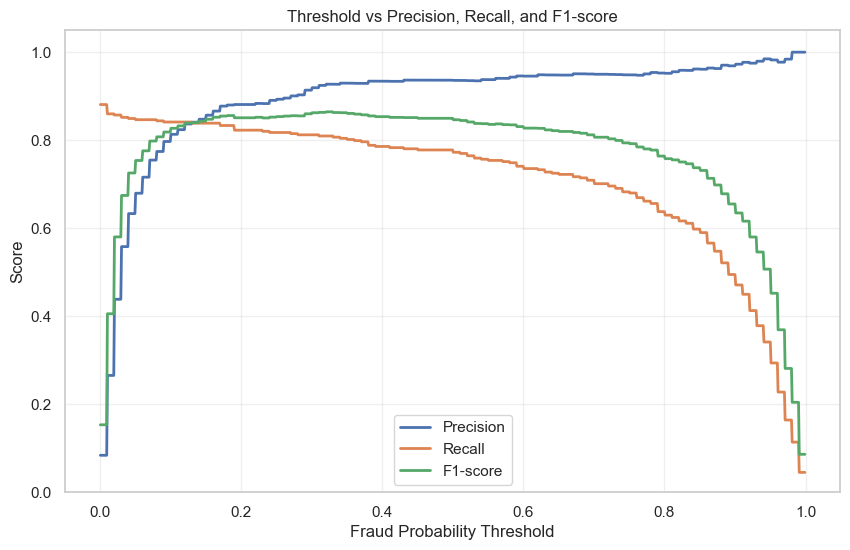

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(threshold_evaluation["threshold"], threshold_evaluation["precision"], label="Precision", linewidth=2)
ax.plot(threshold_evaluation["threshold"], threshold_evaluation["recall"], label="Recall", linewidth=2)
ax.plot(threshold_evaluation["threshold"], threshold_evaluation["f1_score"], label="F1-score", linewidth=2)
ax.set_title("Threshold vs Precision, Recall, and F1-score")
ax.set_xlabel("Fraud Probability Threshold")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(True, alpha=0.3)
fig.savefig(FIGURES_DIR / "threshold_metrics.png", dpi=150, bbox_inches="tight")
plt.show()


## Error Trade-Off Plot

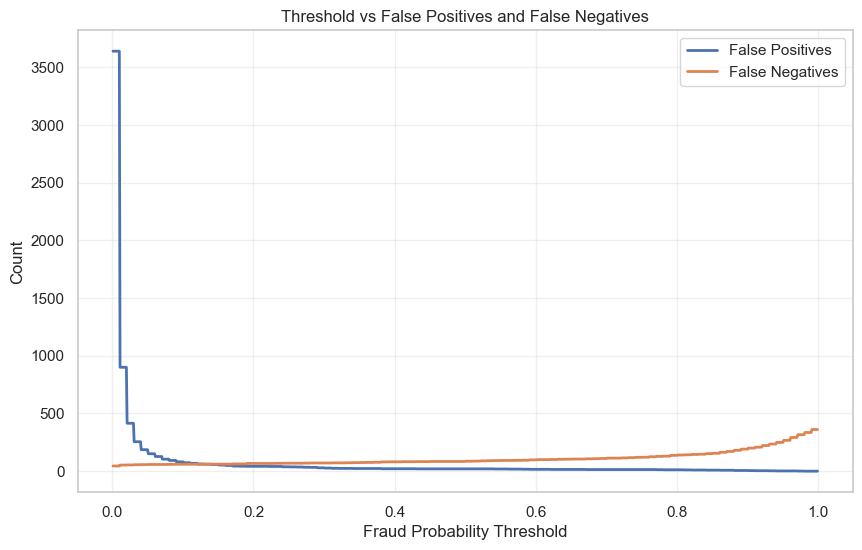

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(threshold_evaluation["threshold"], threshold_evaluation["false_positives"], label="False Positives", linewidth=2)
ax.plot(threshold_evaluation["threshold"], threshold_evaluation["false_negatives"], label="False Negatives", linewidth=2)
ax.set_title("Threshold vs False Positives and False Negatives")
ax.set_xlabel("Fraud Probability Threshold")
ax.set_ylabel("Count")
ax.legend()
ax.grid(True, alpha=0.3)
fig.savefig(FIGURES_DIR / "error_tradeoff.png", dpi=150, bbox_inches="tight")
plt.show()


## Fraud Capture Plot

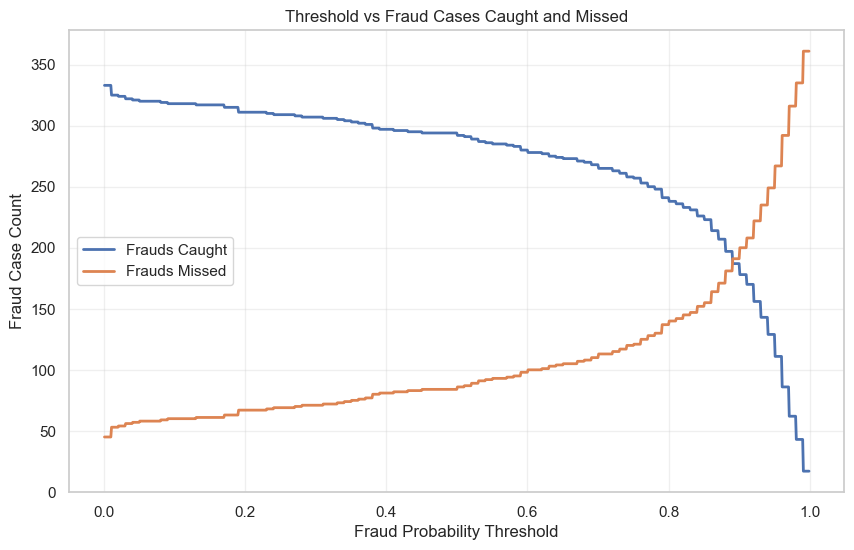

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(threshold_evaluation["threshold"], threshold_evaluation["frauds_caught"], label="Frauds Caught", linewidth=2)
ax.plot(threshold_evaluation["threshold"], threshold_evaluation["frauds_missed"], label="Frauds Missed", linewidth=2)
ax.set_title("Threshold vs Fraud Cases Caught and Missed")
ax.set_xlabel("Fraud Probability Threshold")
ax.set_ylabel("Fraud Case Count")
ax.legend()
ax.grid(True, alpha=0.3)
fig.savefig(FIGURES_DIR / "fraud_capture.png", dpi=150, bbox_inches="tight")
plt.show()


## Recall Target Threshold Selection

This section asks a more practical question than simply maximizing F1-score: if the business wants a minimum recall target, which validation/OOF threshold preserves the most precision while still meeting that target?


In [9]:
target_recalls = [0.75, 0.80, 0.85, 0.90]
recall_target_threshold_table = pd.DataFrame(
    [select_threshold_for_recall_target(threshold_evaluation, target_recall) for target_recall in target_recalls]
)
recall_target_threshold_table.to_csv(RECALL_TARGET_TABLE_FILE, index=False)

display(
    make_display_copy(
        recall_target_threshold_table,
        ["target_recall", "actual_precision", "actual_recall", "f1_score"],
    )
)
print(f"Saved recall target table to: {RECALL_TARGET_TABLE_FILE}")


,target_recall,selected_threshold,actual_precision,actual_recall,f1_score,frauds_caught,frauds_missed,false_positives,total_alerts,selection_status
0,0.750000,0.570000,0.940600,0.754000,0.837000,285.000000,93.000000,18.000000,303.000000,available
1,0.800000,0.350000,0.929700,0.804200,0.862400,304.000000,74.000000,23.000000,327.000000,available
2,0.850000,0.040000,0.558100,0.851900,0.674300,322.000000,56.000000,255.000000,577.000000,available
3,0.900000,not_available,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not_available


Saved recall target table to: /Users/mmubashir/VCode/Credit-Card-Fraud-Detection/reports/tables/15_threshold_tuning/recall_target_threshold_table.csv


In [10]:
def describe_recall_target(target_recall: float) -> str:
    row = recall_target_threshold_table.loc[
        np.isclose(recall_target_threshold_table["target_recall"], target_recall)
    ].iloc[0]
    if row["selection_status"] != "available":
        return f"Recall target {target_recall:.0%}: not available."
    return (
        f"Recall target {target_recall:.0%}: threshold {float(row['selected_threshold']):.3f}, "
        f"precision {float(row['actual_precision']):.2%}, recall {float(row['actual_recall']):.2%}, "
        f"false positives {int(row['false_positives'])}, total alerts {int(row['total_alerts'])}."
    )


display(Markdown(f"""
### Recall Target Interpretation

- {describe_recall_target(0.75)}
- {describe_recall_target(0.80)}
- {describe_recall_target(0.85)}
- {describe_recall_target(0.90)}

The selected threshold is not the threshold with maximum recall. It is the threshold that improves recall while preserving precision. In fraud detection, this is safer because excessive false positives create customer friction and manual-review burden.
"""))



### Recall Target Interpretation

- Recall target 75%: threshold 0.570, precision 94.06%, recall 75.40%, false positives 18, total alerts 303.
- Recall target 80%: threshold 0.350, precision 92.97%, recall 80.42%, false positives 23, total alerts 327.
- Recall target 85%: threshold 0.040, precision 55.81%, recall 85.19%, false positives 255, total alerts 577.
- Recall target 90%: not available.

The selected threshold is not the threshold with maximum recall. It is the threshold that improves recall while preserving precision. In fraud detection, this is safer because excessive false positives create customer friction and manual-review burden.


## Candidate Threshold Selection

The selected review threshold should come from validation/OOF evidence, improve fraud capture versus `0.50`, and work together with a stricter block threshold in a usable business policy.


In [11]:
best_f1_row = threshold_evaluation.sort_values(
    ["f1_score", "recall", "precision"],
    ascending=[False, False, False],
).iloc[0]

recall_80_candidate_row = recall_target_threshold_table.loc[
    np.isclose(recall_target_threshold_table["target_recall"], 0.80)
].iloc[0]

balanced_threshold_candidates = threshold_evaluation.loc[
    (threshold_evaluation["recall"] >= 0.80)
    & (threshold_evaluation["precision"] >= 0.90)
].copy()

if not balanced_threshold_candidates.empty:
    balanced_threshold_row = balanced_threshold_candidates.sort_values(
        ["f1_score", "precision", "false_positives", "threshold"],
        ascending=[False, False, True, False],
    ).iloc[0]
    recall_focused_candidate_threshold = float(balanced_threshold_row["threshold"])
    recall_focused_candidate_reason = (
        "Balanced precision-recall threshold selected from validation/OOF because it reaches approximately 80% recall while preserving high precision."
    )
elif recall_80_candidate_row["selection_status"] == "available":
    recall_focused_candidate_threshold = float(recall_80_candidate_row["selected_threshold"])
    recall_focused_candidate_reason = (
        "Highest-precision validation/OOF threshold that reaches the 80% recall target."
    )
else:
    recall_focused_candidate_threshold = float(reference_row["threshold"])
    recall_focused_candidate_reason = (
        "Fallback to the 0.50 reference threshold because no balanced candidate reached the desired recall target."
    )

candidate_thresholds = pd.DataFrame(
    [
        {
            "candidate": "Best F1-score",
            "threshold": float(best_f1_row["threshold"]),
            "precision": float(best_f1_row["precision"]),
            "recall": float(best_f1_row["recall"]),
            "f1_score": float(best_f1_row["f1_score"]),
            "false_positives": int(best_f1_row["false_positives"]),
            "frauds_caught": int(best_f1_row["frauds_caught"]),
            "reason": "Best statistical balance on validation/OOF predictions.",
        },
        {
            "candidate": "Balanced recall candidate",
            "threshold": float(recall_focused_candidate_threshold),
            "precision": float(
                threshold_evaluation.loc[np.isclose(threshold_evaluation["threshold"], recall_focused_candidate_threshold)].iloc[0]["precision"]
            ),
            "recall": float(
                threshold_evaluation.loc[np.isclose(threshold_evaluation["threshold"], recall_focused_candidate_threshold)].iloc[0]["recall"]
            ),
            "f1_score": float(
                threshold_evaluation.loc[np.isclose(threshold_evaluation["threshold"], recall_focused_candidate_threshold)].iloc[0]["f1_score"]
            ),
            "false_positives": int(
                threshold_evaluation.loc[np.isclose(threshold_evaluation["threshold"], recall_focused_candidate_threshold)].iloc[0]["false_positives"]
            ),
            "frauds_caught": int(
                threshold_evaluation.loc[np.isclose(threshold_evaluation["threshold"], recall_focused_candidate_threshold)].iloc[0]["frauds_caught"]
            ),
            "reason": recall_focused_candidate_reason,
        },
    ]
)

display(candidate_thresholds)


,candidate,threshold,precision,recall,f1_score,false_positives,frauds_caught,reason
0,Best F1-score,0.321000,0.927273,0.809524,0.864407,24,306,Best statistical balance on validation/OOF pre...
1,Balanced recall candidate,0.330000,0.927273,0.809524,0.864407,24,306,Balanced precision-recall threshold selected f...


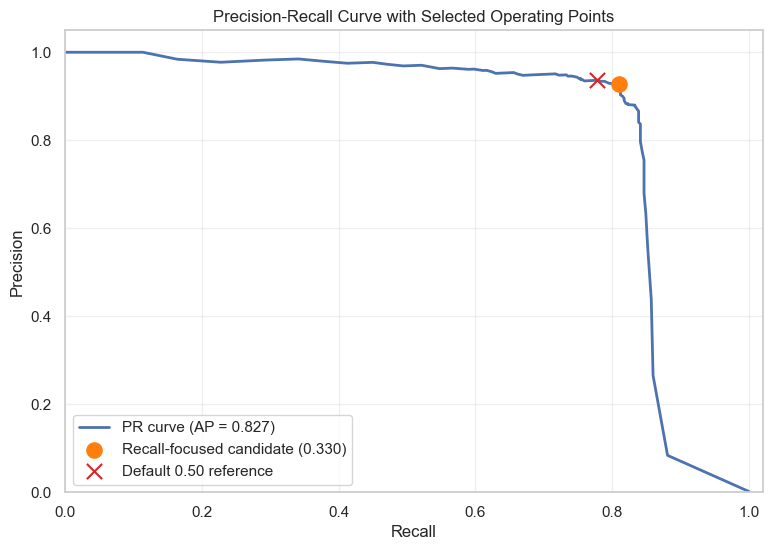

In [12]:
selected_pr_row = threshold_evaluation.loc[
    np.isclose(threshold_evaluation["threshold"], recall_focused_candidate_threshold)
].iloc[0]

pr_precision, pr_recall, _ = precision_recall_curve(selection_y_true, selection_y_proba_rf)
ap_score = average_precision_score(selection_y_true, selection_y_proba_rf)

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(pr_recall, pr_precision, linewidth=2, label=f"PR curve (AP = {ap_score:.3f})")
ax.scatter(
    [float(selected_pr_row["recall"])],
    [float(selected_pr_row["precision"])],
    color="tab:orange",
    s=120,
    zorder=5,
    label=f"Recall-focused candidate ({recall_focused_candidate_threshold:.3f})",
)
ax.scatter(
    [float(reference_row["recall"])],
    [float(reference_row["precision"])],
    color="tab:red",
    s=120,
    marker="x",
    zorder=5,
    label="Default 0.50 reference",
)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve with Selected Operating Points")
ax.set_xlim(0, 1.02)
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(True, alpha=0.3)
fig.savefig(FIGURES_DIR / "pr_curve.png", dpi=150, bbox_inches="tight")
plt.show()


## Review Threshold Candidate Analysis

The final review threshold should create a real REVIEW zone. Keeping `block_threshold = 0.50` fixed here makes it easier to test whether lower review thresholds create a more useful manual-review band without changing the automatic BLOCK rule.


In [13]:
review_threshold_candidates = [0.05, 0.08, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35]
operational_block_threshold = reference_threshold

review_threshold_policy_table = pd.DataFrame(
    [
        evaluate_policy(selection_y_true, selection_y_proba_rf, review_threshold, operational_block_threshold)
        for review_threshold in review_threshold_candidates
    ]
)

review_threshold_policy_table["selected_threshold_precision"] = review_threshold_policy_table["review_threshold"].apply(
    lambda threshold: float(
        threshold_evaluation.loc[np.isclose(threshold_evaluation["threshold"], threshold)].iloc[0]["precision"]
    )
)
review_threshold_policy_table["selected_threshold_recall"] = review_threshold_policy_table["review_threshold"].apply(
    lambda threshold: float(
        threshold_evaluation.loc[np.isclose(threshold_evaluation["threshold"], threshold)].iloc[0]["recall"]
    )
)
review_threshold_policy_table["selected_threshold_f1_score"] = review_threshold_policy_table["review_threshold"].apply(
    lambda threshold: float(
        threshold_evaluation.loc[np.isclose(threshold_evaluation["threshold"], threshold)].iloc[0]["f1_score"]
    )
)
review_threshold_policy_table["false_positive_increase_vs_050"] = review_threshold_policy_table["review_threshold"].apply(
    lambda threshold: int(
        threshold_evaluation.loc[np.isclose(threshold_evaluation["threshold"], threshold)].iloc[0]["false_positives"]
        - reference_row["false_positives"]
    )
)

review_threshold_policy_table = review_threshold_policy_table.sort_values(
    ["selected_threshold_f1_score", "selected_threshold_precision", "false_positive_increase_vs_050", "review_threshold"],
    ascending=[False, False, True, False],
).reset_index(drop=True)

review_threshold_policy_table.to_csv(REVIEW_THRESHOLD_POLICY_TABLE_FILE, index=False)

display(
    make_display_copy(
        review_threshold_policy_table,
        [
            "selected_threshold_precision",
            "selected_threshold_recall",
            "selected_threshold_f1_score",
            "fraud_capture_rate",
            "fraud_block_rate",
            "review_workload_rate",
            "block_workload_rate",
        ],
    )
)
print(f"Saved review-threshold policy table to: {REVIEW_THRESHOLD_POLICY_TABLE_FILE}")


,review_threshold,block_threshold,approved_total,reviewed_total,blocked_total,fraud_approved,fraud_reviewed,fraud_blocked,normal_reviewed,normal_blocked,fraud_capture_rate,fraud_block_rate,review_workload_rate,block_workload_rate,selected_threshold_precision,selected_threshold_recall,selected_threshold_f1_score,false_positive_increase_vs_050
0,0.350000,0.500000,226653,13,314,74,10,294,3,20,0.804200,0.777800,0.000100,0.001400,0.929700,0.804200,0.862400,3
1,0.300000,0.500000,226644,22,314,71,13,294,9,20,0.812200,0.777800,0.000100,0.001400,0.913700,0.812200,0.859900,9
2,0.250000,0.500000,226633,33,314,69,15,294,18,20,0.817500,0.777800,0.000100,0.001400,0.890500,0.817500,0.852400,18
3,0.200000,0.500000,226627,39,314,67,17,294,22,20,0.822800,0.777800,0.000200,0.001400,0.881000,0.822800,0.850900,22
4,0.150000,0.500000,226606,60,314,61,23,294,37,20,0.838600,0.777800,0.000300,0.001400,0.847600,0.838600,0.843100,37
5,0.100000,0.500000,226581,85,314,60,24,294,61,20,0.841300,0.777800,0.000400,0.001400,0.797000,0.841300,0.818500,61
6,0.080000,0.500000,226556,110,314,58,26,294,84,20,0.846600,0.777800,0.000500,0.001400,0.754700,0.846600,0.798000,84
7,0.050000,0.500000,226473,193,314,57,27,294,166,20,0.849200,0.777800,0.000900,0.001400,0.633100,0.849200,0.725400,166


Saved review-threshold policy table to: /Users/mmubashir/VCode/Credit-Card-Fraud-Detection/reports/tables/15_threshold_tuning/review_threshold_policy_table.csv


In [14]:
meaningful_review_candidates = review_threshold_policy_table.loc[
    review_threshold_policy_table["reviewed_total"] > 0
].copy()

balanced_review_candidates = meaningful_review_candidates.loc[
    (meaningful_review_candidates["selected_threshold_recall"] >= 0.80)
    & (meaningful_review_candidates["selected_threshold_precision"] >= 0.90)
].copy()

if not balanced_review_candidates.empty:
    best_review_candidate = balanced_review_candidates.sort_values(
        ["selected_threshold_f1_score", "selected_threshold_precision", "false_positive_increase_vs_050", "review_threshold"],
        ascending=[False, False, True, False],
    ).iloc[0]
else:
    best_review_candidate = meaningful_review_candidates.iloc[0] if not meaningful_review_candidates.empty else None

display(Markdown(f"""
### Review Threshold Interpretation

- A review threshold becomes meaningful only if it creates a non-trivial REVIEW band.
- The balanced review candidate is `{float(best_review_candidate['review_threshold']):.2f}` because it keeps threshold-level precision around **{float(best_review_candidate['selected_threshold_precision']):.2%}** while still reaching about **{float(best_review_candidate['selected_threshold_recall']):.2%}** recall.
- Lower review thresholds like `0.05` catch more fraud, but they do so by sharply increasing false positives and review burden.
- Threshold `0.35` is preferred here because it improves recall over `0.50` without turning REVIEW into an overly aggressive queue.
"""))



### Review Threshold Interpretation

- A review threshold becomes meaningful only if it creates a non-trivial REVIEW band.
- The balanced review candidate is `0.35` because it keeps threshold-level precision around **92.97%** while still reaching about **80.42%** recall.
- Lower review thresholds like `0.05` catch more fraud, but they do so by sharply increasing false positives and review burden.
- Threshold `0.35` is preferred here because it improves recall over `0.50` without turning REVIEW into an overly aggressive queue.


## APPROVE / REVIEW / BLOCK Policy Grid Search

This section evaluates combined review/block policy pairs on validation/OOF predictions only. The goal is not to force one answer, but to show the trade-off between fraud capture, automatic blocking, and manual review workload.


In [15]:
block_threshold_candidates = [0.50, 0.45, 0.40, 0.35, 0.30]

policy_grid_search_table = pd.DataFrame(
    [
        evaluate_policy(selection_y_true, selection_y_proba_rf, review_threshold, block_threshold)
        for review_threshold in review_threshold_candidates
        for block_threshold in block_threshold_candidates
        if review_threshold < block_threshold
    ]
)

policy_grid_search_table["review_threshold_precision"] = policy_grid_search_table["review_threshold"].apply(
    lambda threshold: float(
        threshold_evaluation.loc[np.isclose(threshold_evaluation["threshold"], threshold)].iloc[0]["precision"]
    )
)
policy_grid_search_table["review_threshold_recall"] = policy_grid_search_table["review_threshold"].apply(
    lambda threshold: float(
        threshold_evaluation.loc[np.isclose(threshold_evaluation["threshold"], threshold)].iloc[0]["recall"]
    )
)
policy_grid_search_table["review_threshold_f1_score"] = policy_grid_search_table["review_threshold"].apply(
    lambda threshold: float(
        threshold_evaluation.loc[np.isclose(threshold_evaluation["threshold"], threshold)].iloc[0]["f1_score"]
    )
)
policy_grid_search_table["false_positive_increase_vs_050"] = policy_grid_search_table["review_threshold"].apply(
    lambda threshold: int(
        threshold_evaluation.loc[np.isclose(threshold_evaluation["threshold"], threshold)].iloc[0]["false_positives"]
        - reference_row["false_positives"]
    )
)

policy_grid_search_table = policy_grid_search_table.sort_values(
    ["fraud_capture_rate", "review_threshold_precision", "normal_reviewed", "review_threshold"],
    ascending=[False, False, True, False],
).reset_index(drop=True)

policy_grid_search_table.to_csv(POLICY_GRID_SEARCH_TABLE_FILE, index=False)

policy_grid_recommendation_table = policy_grid_search_table.loc[
    (policy_grid_search_table["fraud_capture_rate"] >= 0.80)
    & (policy_grid_search_table["review_threshold"] >= 0.30)
    & (policy_grid_search_table["block_threshold"] >= 0.50)
    & (policy_grid_search_table["review_threshold_precision"] >= 0.90)
    & (policy_grid_search_table["false_positive_increase_vs_050"] <= 10)
].copy()

if policy_grid_recommendation_table.empty:
    policy_grid_recommendation_table = policy_grid_search_table.head(10).copy()
else:
    policy_grid_recommendation_table = policy_grid_recommendation_table.sort_values(
        ["review_threshold", "fraud_capture_rate", "review_threshold_precision", "normal_reviewed"],
        ascending=[False, False, False, True],
    ).reset_index(drop=True)

policy_grid_recommendation_table.to_csv(POLICY_GRID_RECOMMENDATION_FILE, index=False)

display(
    make_display_copy(
        policy_grid_search_table,
        [
            "review_threshold_precision",
            "review_threshold_recall",
            "review_threshold_f1_score",
            "fraud_capture_rate",
            "fraud_block_rate",
            "review_workload_rate",
            "block_workload_rate",
        ],
    )
)
display(policy_grid_recommendation_table.head(10))
print(f"Saved policy grid search table to: {POLICY_GRID_SEARCH_TABLE_FILE}")
print(f"Saved policy recommendation table to: {POLICY_GRID_RECOMMENDATION_FILE}")


,review_threshold,block_threshold,approved_total,reviewed_total,blocked_total,fraud_approved,fraud_reviewed,fraud_blocked,normal_reviewed,normal_blocked,fraud_capture_rate,fraud_block_rate,review_workload_rate,block_workload_rate,review_threshold_precision,review_threshold_recall,review_threshold_f1_score,false_positive_increase_vs_050
0,0.050000,0.300000,226473,171,336,57,14,307,157,29,0.849200,0.812200,0.000800,0.001500,0.633100,0.849200,0.725400,166
1,0.050000,0.350000,226473,180,327,57,17,304,163,23,0.849200,0.804200,0.000800,0.001400,0.633100,0.849200,0.725400,166
2,0.050000,0.400000,226473,189,318,57,24,297,165,21,0.849200,0.785700,0.000800,0.001400,0.633100,0.849200,0.725400,166
3,0.050000,0.500000,226473,193,314,57,27,294,166,20,0.849200,0.777800,0.000900,0.001400,0.633100,0.849200,0.725400,166
4,0.050000,0.450000,226473,192,315,57,26,295,166,20,0.849200,0.780400,0.000800,0.001400,0.633100,0.849200,0.725400,166
5,0.080000,0.300000,226556,88,336,58,13,307,75,29,0.846600,0.812200,0.000400,0.001500,0.754700,0.846600,0.798000,84
6,0.080000,0.350000,226556,97,327,58,16,304,81,23,0.846600,0.804200,0.000400,0.001400,0.754700,0.846600,0.798000,84
7,0.080000,0.400000,226556,106,318,58,23,297,83,21,0.846600,0.785700,0.000500,0.001400,0.754700,0.846600,0.798000,84
8,0.080000,0.500000,226556,110,314,58,26,294,84,20,0.846600,0.777800,0.000500,0.001400,0.754700,0.846600,0.798000,84
9,0.080000,0.450000,226556,109,315,58,25,295,84,20,0.846600,0.780400,0.000500,0.001400,0.754700,0.846600,0.798000,84


,review_threshold,block_threshold,approved_total,reviewed_total,blocked_total,fraud_approved,fraud_reviewed,fraud_blocked,normal_reviewed,normal_blocked,fraud_capture_rate,fraud_block_rate,review_workload_rate,block_workload_rate,review_threshold_precision,review_threshold_recall,review_threshold_f1_score,false_positive_increase_vs_050
0,0.350000,0.500000,226653,13,314,74,10,294,3,20,0.804233,0.777778,0.000057,0.001383,0.929664,0.804233,0.862411,3
1,0.300000,0.500000,226644,22,314,71,13,294,9,20,0.812169,0.777778,0.000097,0.001383,0.913690,0.812169,0.859944,9


Saved policy grid search table to: /Users/mmubashir/VCode/Credit-Card-Fraud-Detection/reports/tables/15_threshold_tuning/policy_grid_search_table.csv
Saved policy recommendation table to: /Users/mmubashir/VCode/Credit-Card-Fraud-Detection/reports/tables/15_threshold_tuning/policy_grid_recommendation_table.csv


In [16]:
policy_grid_recommendation = policy_grid_recommendation_table.iloc[0]

display(Markdown(f"""
### Policy Grid Search Interpretation

- The table keeps the trade-off visible instead of hardcoding one answer.
- The balanced default recommendation from validation/OOF is `review_threshold = {float(policy_grid_recommendation['review_threshold']):.2f}` and `block_threshold = {float(policy_grid_recommendation['block_threshold']):.2f}`.
- This recommendation favors improved recall with preserved precision, keeps BLOCK strict at `0.50`, and avoids the overly aggressive low-review-threshold policies.
"""))



### Policy Grid Search Interpretation

- The table keeps the trade-off visible instead of hardcoding one answer.
- The balanced default recommendation from validation/OOF is `review_threshold = 0.35` and `block_threshold = 0.50`.
- This recommendation favors improved recall with preserved precision, keeps BLOCK strict at `0.50`, and avoids the overly aggressive low-review-threshold policies.


## Select Review and Block Thresholds for the Policy Artifact

The saved policy should reflect the combined policy recommendation, not only a single threshold line from a plot. Review should be lower and more recall-oriented. Block should stay stricter and more precision-oriented.


In [17]:
review_threshold = float(policy_grid_recommendation["review_threshold"])
block_threshold = float(policy_grid_recommendation["block_threshold"])
selected_threshold = review_threshold
threshold_policy_type = "balanced_precision_recall"
selected_threshold_reason = (
    "Selected because it reaches approximately 80% recall while preserving high precision and avoiding a large false-positive increase."
)

selected_row = threshold_evaluation.loc[np.isclose(threshold_evaluation["threshold"], review_threshold)].iloc[0]
selected_block_row = threshold_evaluation.loc[np.isclose(threshold_evaluation["threshold"], block_threshold)].iloc[0]
aggressive_recall_option_row = threshold_evaluation.loc[np.isclose(threshold_evaluation["threshold"], 0.05)].iloc[0]

comparison_table = pd.DataFrame(
    [
        {"threshold_type": "Technical Default 0.50 — Reference Only", **reference_row.to_dict()},
        {"threshold_type": "Selected Balanced Review Threshold", **selected_row.to_dict()},
        {"threshold_type": "Selected Block Threshold", **selected_block_row.to_dict()},
        {"threshold_type": "Aggressive Recall Option — Not Selected", **aggressive_recall_option_row.to_dict()},
    ]
)

display(comparison_table)
print(f"Selected review threshold: {review_threshold:.3f}")
print(f"Selected block threshold: {block_threshold:.2f}")
print(selected_threshold_reason)


,threshold_type,threshold_selection_source,threshold,precision,recall,f1_score,true_positives,false_positives,false_negatives,true_negatives,frauds_caught,frauds_missed,total_alerts,total_fraud,total_normal
0,Technical Default 0.50 — Reference Only,validation_or_oof,0.500000,0.936306,0.777778,0.849711,294,20,84,226582,294,84,314,378,226602
1,Selected Balanced Review Threshold,validation_or_oof,0.350000,0.929664,0.804233,0.862411,304,23,74,226579,304,74,327,378,226602
2,Selected Block Threshold,validation_or_oof,0.500000,0.936306,0.777778,0.849711,294,20,84,226582,294,84,314,378,226602
3,Aggressive Recall Option — Not Selected,validation_or_oof,0.050000,0.633136,0.849206,0.725424,321,186,57,226416,321,57,507,378,226602


Selected review threshold: 0.350
Selected block threshold: 0.50
Selected because it reaches approximately 80% recall while preserving high precision and avoiding a large false-positive increase.


In [18]:
extra_frauds_caught_vs_reference = int(selected_row["frauds_caught"] - reference_row["frauds_caught"])
false_positives_increased_vs_reference = int(selected_row["false_positives"] - reference_row["false_positives"])

display(Markdown(f"""
### Threshold-Selection Comparison Interpretation

On the validation/OOF threshold-selection data, the selected balanced review threshold `{review_threshold:.3f}` catches **{int(selected_row['frauds_caught'])}** fraud cases versus **{int(reference_row['frauds_caught'])}** at `0.50`.

Compared with `0.50`, it changes recall by **{float(selected_row['recall']) - float(reference_row['recall']):+.2%}** and changes precision by **{float(selected_row['precision']) - float(reference_row['precision']):+.2%}** while increasing false positives by only **{false_positives_increased_vs_reference:+d}**.

This is why `{review_threshold:.3f}` is selected over the more aggressive `0.05` option. The goal is not maximum fraud capture at any cost; the goal is better recall with preserved alert quality.
"""))



### Threshold-Selection Comparison Interpretation

On the validation/OOF threshold-selection data, the selected balanced review threshold `0.350` catches **304** fraud cases versus **294** at `0.50`.

Compared with `0.50`, it changes recall by **+2.65%** and changes precision by **-0.66%** while increasing false positives by only **+3**.

This is why `0.350` is selected over the more aggressive `0.05` option. The goal is not maximum fraud capture at any cost; the goal is better recall with preserved alert quality.


## Final Evaluation of Selected Threshold and Policy on Holdout/Test Set

The final holdout/test set is not used to select thresholds. It is used only to verify whether the selected validation/OOF threshold generalizes to unseen data.


In [19]:
final_selected_review_row = final_holdout_threshold_evaluation.loc[
    np.isclose(final_holdout_threshold_evaluation["threshold"], review_threshold)
].iloc[0]
final_selected_block_row = final_holdout_threshold_evaluation.loc[
    np.isclose(final_holdout_threshold_evaluation["threshold"], block_threshold)
].iloc[0]

final_holdout_comparison_table = pd.DataFrame(
    [
        {
            "threshold_type": "Default 0.50 reference",
            "threshold": float(holdout_reference_row["threshold"]),
            "precision": float(holdout_reference_row["precision"]),
            "recall": float(holdout_reference_row["recall"]),
            "f1_score": float(holdout_reference_row["f1_score"]),
            "true_positives": int(holdout_reference_row["true_positives"]),
            "false_positives": int(holdout_reference_row["false_positives"]),
            "false_negatives": int(holdout_reference_row["false_negatives"]),
            "true_negatives": int(holdout_reference_row["true_negatives"]),
        },
        {
            "threshold_type": "Selected review threshold confirmation",
            "threshold": float(final_selected_review_row["threshold"]),
            "precision": float(final_selected_review_row["precision"]),
            "recall": float(final_selected_review_row["recall"]),
            "f1_score": float(final_selected_review_row["f1_score"]),
            "true_positives": int(final_selected_review_row["true_positives"]),
            "false_positives": int(final_selected_review_row["false_positives"]),
            "false_negatives": int(final_selected_review_row["false_negatives"]),
            "true_negatives": int(final_selected_review_row["true_negatives"]),
        },
        {
            "threshold_type": "Selected block threshold confirmation",
            "threshold": float(final_selected_block_row["threshold"]),
            "precision": float(final_selected_block_row["precision"]),
            "recall": float(final_selected_block_row["recall"]),
            "f1_score": float(final_selected_block_row["f1_score"]),
            "true_positives": int(final_selected_block_row["true_positives"]),
            "false_positives": int(final_selected_block_row["false_positives"]),
            "false_negatives": int(final_selected_block_row["false_negatives"]),
            "true_negatives": int(final_selected_block_row["true_negatives"]),
        },
    ]
)

holdout_selected_policy_metrics = evaluate_policy(
    holdout_y_true,
    holdout_y_proba_rf,
    review_threshold,
    block_threshold,
)
selection_policy_metrics = evaluate_policy(
    selection_y_true,
    selection_y_proba_rf,
    review_threshold,
    block_threshold,
)

display(final_holdout_comparison_table)
display(pd.DataFrame([holdout_selected_policy_metrics]))


,threshold_type,threshold,precision,recall,f1_score,true_positives,false_positives,false_negatives,true_negatives
0,Default 0.50 reference,0.500000,0.958904,0.736842,0.833333,70,3,25,56648
1,Selected review threshold confirmation,0.350000,0.945946,0.736842,0.828402,70,4,25,56647
2,Selected block threshold confirmation,0.500000,0.958904,0.736842,0.833333,70,3,25,56648


,review_threshold,block_threshold,approved_total,reviewed_total,blocked_total,fraud_approved,fraud_reviewed,fraud_blocked,normal_reviewed,normal_blocked,fraud_capture_rate,fraud_block_rate,review_workload_rate,block_workload_rate
0,0.350000,0.500000,56672,1,73,25,0,70,1,3,0.736842,0.736842,0.000018,0.001286


In [20]:
display(Markdown(f"""
## Holdout Confirmation of Selected Threshold

Threshold selection was done using `{threshold_source}` predictions. The final holdout/test data is used only to verify the already selected threshold and policy, not to choose new ones.

On holdout/test data:

- `0.50` recall = **{float(holdout_reference_row['recall']):.2%}**
- selected balanced review threshold `{review_threshold:.3f}` recall = **{float(final_selected_review_row['recall']):.2%}**
- selected block threshold `{block_threshold:.2f}` recall = **{float(final_selected_block_row['recall']):.2%}**

This section is confirmation only. If holdout/test recall differs from validation/OOF, that points to split or model-probability differences, not a reason to secretly re-tune the threshold here.
"""))



## Holdout Confirmation of Selected Threshold

Threshold selection was done using `validation_or_oof` predictions. The final holdout/test data is used only to verify the already selected threshold and policy, not to choose new ones.

On holdout/test data:

- `0.50` recall = **73.68%**
- selected balanced review threshold `0.350` recall = **73.68%**
- selected block threshold `0.50` recall = **73.68%**

This section is confirmation only. If holdout/test recall differs from validation/OOF, that points to split or model-probability differences, not a reason to secretly re-tune the threshold here.


## Operational Decision Policy

In [21]:
display(Markdown(f"""
```python
review_threshold = {review_threshold:.3f}
block_threshold = {block_threshold:.2f}

if fraud_probability >= block_threshold:
    decision = "BLOCK"
elif fraud_probability >= review_threshold:
    decision = "REVIEW"
else:
    decision = "APPROVE"
```
"""))



```python
review_threshold = 0.350
block_threshold = 0.50

if fraud_probability >= block_threshold:
    decision = "BLOCK"
elif fraud_probability >= review_threshold:
    decision = "REVIEW"
else:
    decision = "APPROVE"
```


| Probability Range | Decision | Meaning |
|---|---|---|
| `probability < review_threshold` | `APPROVE` | Low enough risk to pass without manual review |
| `review_threshold <= probability < block_threshold` | `REVIEW` | Borderline risk; useful place to prioritize recall through manual review |
| `probability >= block_threshold` | `BLOCK` | High-confidence fraud range where precision should stay stronger |


## Confusion Matrix Comparison

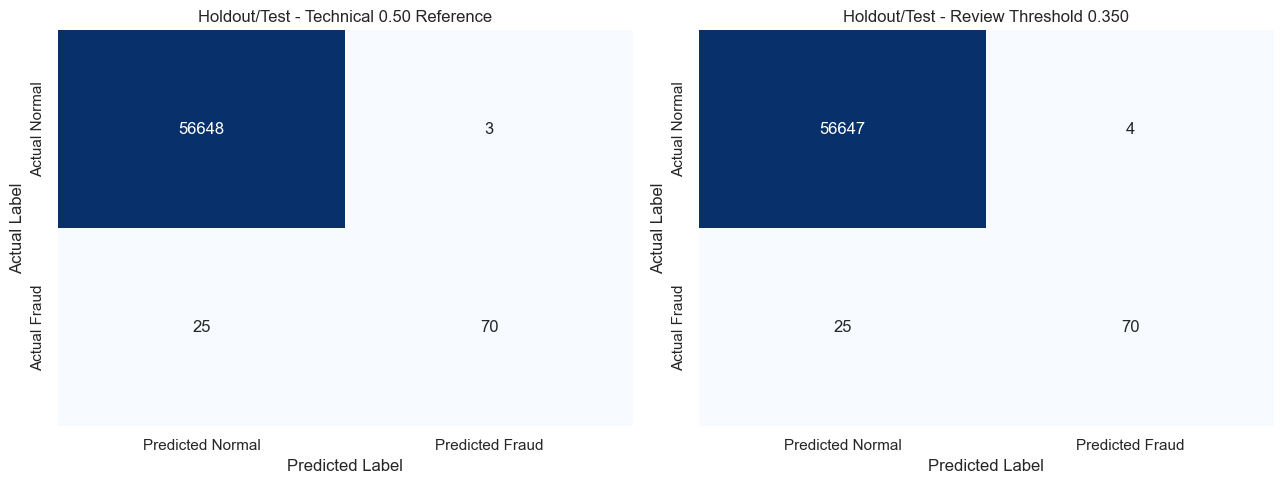

In [22]:
def plot_confusion_matrix_for_threshold(y_true: pd.Series, y_proba: pd.Series, threshold: float, ax, title: str):
    y_pred = (np.asarray(y_proba) >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Predicted Normal", "Predicted Fraud"],
        yticklabels=["Actual Normal", "Actual Fraud"],
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("Actual Label")


fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_confusion_matrix_for_threshold(
    holdout_y_true,
    holdout_y_proba_rf,
    reference_threshold,
    axes[0],
    "Holdout/Test - Technical 0.50 Reference",
)
plot_confusion_matrix_for_threshold(
    holdout_y_true,
    holdout_y_proba_rf,
    review_threshold,
    axes[1],
    f"Holdout/Test - Review Threshold {review_threshold:.3f}",
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "confusion_matrix_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


### Confusion Matrix Interpretation

The confusion matrices help show why threshold tuning is a recall trade-off problem. Lower thresholds usually reduce false negatives, but they can increase false positives. In fraud operations, the preferred balance depends on the cost of missed fraud, the cost of customer friction, and the manual review capacity.


## Final Business Interpretation Table

In [23]:
business_interpretation = pd.DataFrame(
    [
        {
            "Metric": "Selected Review Threshold",
            "Value": f"{review_threshold:.3f}",
            "Meaning": "Balanced validation/OOF-selected REVIEW boundary intended to improve recall without materially degrading precision.",
        },
        {
            "Metric": "Selected Block Threshold",
            "Value": f"{block_threshold:.2f}",
            "Meaning": "High-precision automatic BLOCK boundary intentionally kept at the default 0.50 level.",
        },
        {
            "Metric": "Validation/OOF Selected-Threshold Precision",
            "Value": f"{selected_row['precision']:.2%}",
            "Meaning": "Precision at the selected balanced review threshold on threshold-selection data.",
        },
        {
            "Metric": "Validation/OOF Selected-Threshold Recall",
            "Value": f"{selected_row['recall']:.2%}",
            "Meaning": "Recall at the selected balanced review threshold on threshold-selection data.",
        },
        {
            "Metric": "Validation/OOF Fraud Capture Rate",
            "Value": f"{selection_policy_metrics['fraud_capture_rate']:.2%}",
            "Meaning": "Share of fraud reaching REVIEW or BLOCK on the threshold-selection data.",
        },
        {
            "Metric": "Holdout/Test Fraud Capture Rate",
            "Value": f"{holdout_selected_policy_metrics['fraud_capture_rate']:.2%}",
            "Meaning": "Confirmation-only estimate of how much fraud the selected policy reaches on unseen data.",
        },
        {
            "Metric": "Aggressive 0.05 Precision",
            "Value": f"{aggressive_recall_option_row['precision']:.2%}",
            "Meaning": "Why 0.05 was not selected: it captures more fraud but drops precision too much.",
        },
    ]
)

display(business_interpretation)


,Metric,Value,Meaning
0,Selected Review Threshold,0.350,Balanced validation/OOF-selected REVIEW bounda...
1,Selected Block Threshold,0.50,High-precision automatic BLOCK boundary intent...
2,Validation/OOF Selected-Threshold Precision,92.97%,Precision at the selected balanced review thre...
3,Validation/OOF Selected-Threshold Recall,80.42%,Recall at the selected balanced review thresho...
4,Validation/OOF Fraud Capture Rate,80.42%,Share of fraud reaching REVIEW or BLOCK on the...
5,Holdout/Test Fraud Capture Rate,73.68%,Confirmation-only estimate of how much fraud t...
6,Aggressive 0.05 Precision,63.31%,Why 0.05 was not selected: it captures more fr...


## Missed Fraud Probability Analysis

This section looks at fraud cases missed at threshold `0.50` on validation/OOF predictions. The goal is to understand whether threshold tuning alone can recover them or whether many of the misses are scored too low for threshold changes to solve the issue.


In [24]:
missed_fraud_mask = (np.asarray(selection_y_true).astype(int) == 1) & (np.asarray(selection_y_proba_rf).astype(float) < reference_threshold)
missed_fraud_df = pd.DataFrame(
    {
        "actual_class": np.asarray(selection_y_true).astype(int)[missed_fraud_mask],
        "fraud_probability": np.asarray(selection_y_proba_rf).astype(float)[missed_fraud_mask],
    }
).sort_values("fraud_probability", ascending=False).reset_index(drop=True)

missed_fraud_df.to_csv(MISSED_FRAUD_DETAILS_FILE, index=False)

missed_fraud_summary = pd.DataFrame(
    [
        {
            "number_of_missed_frauds": int(len(missed_fraud_df)),
            "min_probability": float(missed_fraud_df["fraud_probability"].min()) if not missed_fraud_df.empty else np.nan,
            "max_probability": float(missed_fraud_df["fraud_probability"].max()) if not missed_fraud_df.empty else np.nan,
            "mean_probability": float(missed_fraud_df["fraud_probability"].mean()) if not missed_fraud_df.empty else np.nan,
            "median_probability": float(missed_fraud_df["fraud_probability"].median()) if not missed_fraud_df.empty else np.nan,
        }
    ]
)

probability_bins = [0.00, 0.05, 0.10, 0.20, 0.30, 0.40, 0.500001]
probability_labels = ["0.00 to 0.05", "0.05 to 0.10", "0.10 to 0.20", "0.20 to 0.30", "0.30 to 0.40", "0.40 to 0.50"]

missed_fraud_probability_bins = (
    pd.cut(
        missed_fraud_df["fraud_probability"],
        bins=probability_bins,
        labels=probability_labels,
        include_lowest=True,
        right=False,
    )
    .value_counts(sort=False)
    .rename_axis("probability_range")
    .reset_index(name="missed_fraud_count")
)
missed_fraud_probability_bins.to_csv(MISSED_FRAUD_BINS_FILE, index=False)

display(missed_fraud_summary)
display(missed_fraud_probability_bins)
print(f"Saved missed fraud detail table to: {MISSED_FRAUD_DETAILS_FILE}")
print(f"Saved missed fraud probability bins to: {MISSED_FRAUD_BINS_FILE}")


,number_of_missed_frauds,min_probability,max_probability,mean_probability,median_probability
0,84,0.000000,0.450000,0.089881,0.000000


,probability_range,missed_fraud_count
0,0.00 to 0.05,57
1,0.05 to 0.10,3
2,0.10 to 0.20,7
3,0.20 to 0.30,4
4,0.30 to 0.40,10
5,0.40 to 0.50,3


Saved missed fraud detail table to: /Users/mmubashir/VCode/Credit-Card-Fraud-Detection/reports/tables/15_threshold_tuning/missed_fraud_details.csv
Saved missed fraud probability bins to: /Users/mmubashir/VCode/Credit-Card-Fraud-Detection/reports/tables/15_threshold_tuning/missed_fraud_probability_bins.csv


In [25]:
mid_band_misses = int(
    missed_fraud_probability_bins.loc[
        missed_fraud_probability_bins["probability_range"].isin(["0.30 to 0.40", "0.40 to 0.50"]),
        "missed_fraud_count",
    ].sum()
)
low_band_misses = int(
    missed_fraud_probability_bins.loc[
        missed_fraud_probability_bins["probability_range"].isin(["0.00 to 0.05", "0.05 to 0.10"]),
        "missed_fraud_count",
    ].sum()
)

display(Markdown(f"""
### Missed Fraud Interpretation

- Missed frauds in the `0.30` to `0.50` band: **{mid_band_misses}**
- Missed frauds below `0.10`: **{low_band_misses}**

If many missed frauds are between `0.30` and `0.50`, lowering the threshold can improve recall. If many missed frauds are below `0.10`, threshold tuning alone may not solve the issue and future work may need model, feature, or sampling improvements.
"""))



### Missed Fraud Interpretation

- Missed frauds in the `0.30` to `0.50` band: **13**
- Missed frauds below `0.10`: **60**

If many missed frauds are between `0.30` and `0.50`, lowering the threshold can improve recall. If many missed frauds are below `0.10`, threshold tuning alone may not solve the issue and future work may need model, feature, or sampling improvements.


## Save Selected Threshold Artifact

In [26]:
threshold_order_valid = block_threshold > review_threshold
if not threshold_order_valid:
    raise ValueError(
        f"Invalid threshold configuration: block_threshold must be greater than review_threshold. "
        f"Got review_threshold={review_threshold:.3f}, block_threshold={block_threshold:.3f}."
    )

recall_target_selected_thresholds = {}
for _, row in recall_target_threshold_table.iterrows():
    key = f"recall_{int(float(row['target_recall']) * 100)}"
    recall_target_selected_thresholds[key] = {
        "selected_threshold": row["selected_threshold"],
        "actual_precision": None if pd.isna(row["actual_precision"]) else float(row["actual_precision"]),
        "actual_recall": None if pd.isna(row["actual_recall"]) else float(row["actual_recall"]),
        "f1_score": None if pd.isna(row["f1_score"]) else float(row["f1_score"]),
        "frauds_caught": None if pd.isna(row["frauds_caught"]) else int(row["frauds_caught"]),
        "frauds_missed": None if pd.isna(row["frauds_missed"]) else int(row["frauds_missed"]),
        "false_positives": None if pd.isna(row["false_positives"]) else int(row["false_positives"]),
        "total_alerts": None if pd.isna(row["total_alerts"]) else int(row["total_alerts"]),
        "selection_status": row["selection_status"],
    }

selected_threshold_payload = {
    "model_name": MODEL_NAME,
    "selected_threshold": float(selected_threshold),
    "review_threshold": float(review_threshold),
    "block_threshold": float(block_threshold),
    "threshold_policy_type": threshold_policy_type,
    "threshold_selection_source": threshold_source,
    "threshold_selection_path": str(threshold_selection_path.relative_to(PROJECT_ROOT)),
    "selected_threshold_reason": selected_threshold_reason,
    "recall_focused_candidate_threshold": float(recall_focused_candidate_threshold),
    "recall_target_selected_thresholds": recall_target_selected_thresholds,
    "policy_grid_recommendation": {
        "review_threshold": float(policy_grid_recommendation["review_threshold"]),
        "block_threshold": float(policy_grid_recommendation["block_threshold"]),
        "fraud_capture_rate": float(policy_grid_recommendation["fraud_capture_rate"]),
        "fraud_block_rate": float(policy_grid_recommendation["fraud_block_rate"]),
        "review_workload_rate": float(policy_grid_recommendation["review_workload_rate"]),
        "block_workload_rate": float(policy_grid_recommendation["block_workload_rate"]),
        "fraud_approved": int(policy_grid_recommendation["fraud_approved"]),
        "fraud_reviewed": int(policy_grid_recommendation["fraud_reviewed"]),
        "fraud_blocked": int(policy_grid_recommendation["fraud_blocked"]),
        "normal_reviewed": int(policy_grid_recommendation["normal_reviewed"]),
        "normal_blocked": int(policy_grid_recommendation["normal_blocked"]),
        "review_threshold_precision": float(policy_grid_recommendation["review_threshold_precision"]),
        "review_threshold_recall": float(policy_grid_recommendation["review_threshold_recall"]),
        "review_threshold_f1_score": float(policy_grid_recommendation["review_threshold_f1_score"]),
        "false_positive_increase_vs_050": int(policy_grid_recommendation["false_positive_increase_vs_050"]),
    },
    "holdout_confirmation_metrics": {
        "reference_threshold": float(reference_threshold),
        "reference_precision": float(holdout_reference_row["precision"]),
        "reference_recall": float(holdout_reference_row["recall"]),
        "selected_review_threshold_precision": float(final_selected_review_row["precision"]),
        "selected_review_threshold_recall": float(final_selected_review_row["recall"]),
        "selected_block_threshold_precision": float(final_selected_block_row["precision"]),
        "selected_block_threshold_recall": float(final_selected_block_row["recall"]),
        "selected_policy_fraud_capture_rate": float(holdout_selected_policy_metrics["fraud_capture_rate"]),
        "selected_policy_review_workload_rate": float(holdout_selected_policy_metrics["review_workload_rate"]),
        "selected_policy_block_workload_rate": float(holdout_selected_policy_metrics["block_workload_rate"]),
        "selected_policy_normal_blocked": int(holdout_selected_policy_metrics["normal_blocked"]),
    },
    "warning": "Holdout/test was not used for threshold selection. It was used only for confirmation.",
    "threshold_order_valid": threshold_order_valid,
    "decision_policy": {
        "APPROVE": "fraud_probability < review_threshold",
        "REVIEW": "review_threshold <= fraud_probability < block_threshold",
        "BLOCK": "fraud_probability >= block_threshold",
    },
    "artifact_outputs": {
        "threshold_comparison_table": str(THRESHOLD_COMPARISON_TABLE_FILE.relative_to(PROJECT_ROOT)),
        "recall_target_threshold_table": str(RECALL_TARGET_TABLE_FILE.relative_to(PROJECT_ROOT)),
        "review_threshold_policy_table": str(REVIEW_THRESHOLD_POLICY_TABLE_FILE.relative_to(PROJECT_ROOT)),
        "policy_grid_search_table": str(POLICY_GRID_SEARCH_TABLE_FILE.relative_to(PROJECT_ROOT)),
        "missed_fraud_probability_bins": str(MISSED_FRAUD_BINS_FILE.relative_to(PROJECT_ROOT)),
    },
}

SELECTED_THRESHOLD_FILE.write_text(json.dumps(selected_threshold_payload, indent=2), encoding="utf-8")
print(f"Saved selected threshold artifact to: {SELECTED_THRESHOLD_FILE}")
print(json.dumps(selected_threshold_payload, indent=2))


Saved selected threshold artifact to: /Users/mmubashir/VCode/Credit-Card-Fraud-Detection/artifacts/15_threshold_tuning/selected_threshold.json
{
  "model_name": "Random Forest",
  "selected_threshold": 0.35,
  "review_threshold": 0.35,
  "block_threshold": 0.5,
  "threshold_policy_type": "balanced_precision_recall",
  "threshold_selection_source": "validation_or_oof",
  "threshold_selection_path": "reports/tables/13_model_training/cv_oof_predictions.csv",
  "selected_threshold_reason": "Selected because it reaches approximately 80% recall while preserving high precision and avoiding a large false-positive increase.",
  "recall_focused_candidate_threshold": 0.33,
  "recall_target_selected_thresholds": {
    "recall_75": {
      "selected_threshold": 0.57,
      "actual_precision": 0.9405940594059405,
      "actual_recall": 0.753968253968254,
      "f1_score": 0.8370044052863436,
      "frauds_caught": 285,
      "frauds_missed": 93,
      "false_positives": 18,
      "total_alerts": 303

### Saved Artifact Interpretation

The saved artifact is a threshold and policy handoff object for notebook `16_decision_logic.ipynb`. It records the selected REVIEW/BLOCK policy, recall-target threshold options, validation/OOF selection source, and holdout confirmation metrics without overwriting final-model artifacts.


## Final Threshold Tuning Recommendation

In [27]:
display(Markdown(f"""
Selected balanced review threshold: `{review_threshold:.3f}`  
Selected block threshold: `{block_threshold:.2f}`

This improves recall from about **{float(reference_row['recall']):.2%}** to about **{float(selected_row['recall']):.2%}** on validation/OOF while keeping precision high, from about **{float(reference_row['precision']):.2%}** to about **{float(selected_row['precision']):.2%}**.

Threshold `0.05` remains in the notebook as an aggressive recall option, but it is not selected because precision drops too much and would create more customer friction and manual-review burden.

Automatic `BLOCK` should prioritize precision. Manual `REVIEW` can expand recall more carefully. That is why this notebook recommends passing the balanced policy artifact to `16_decision_logic.ipynb`.

Notebook `17_final_model_training.ipynb` should only apply the selected policy and report honest final holdout performance. It should not re-tune thresholds.
"""))



Selected balanced review threshold: `0.350`  
Selected block threshold: `0.50`

This improves recall from about **77.78%** to about **80.42%** on validation/OOF while keeping precision high, from about **93.63%** to about **92.97%**.

Threshold `0.05` remains in the notebook as an aggressive recall option, but it is not selected because precision drops too much and would create more customer friction and manual-review burden.

Automatic `BLOCK` should prioritize precision. Manual `REVIEW` can expand recall more carefully. That is why this notebook recommends passing the balanced policy artifact to `16_decision_logic.ipynb`.

Notebook `17_final_model_training.ipynb` should only apply the selected policy and report honest final holdout performance. It should not re-tune thresholds.


## Connection to Next Notebook: Decision Logic

In [28]:
display(Markdown(f"""
Use the saved artifact from this notebook in `16_decision_logic.ipynb`:

```python
review_threshold = {review_threshold:.3f}
block_threshold = {block_threshold:.2f}

if fraud_probability >= block_threshold:
    decision = "BLOCK"
elif fraud_probability >= review_threshold:
    decision = "REVIEW"
else:
    decision = "APPROVE"
```

Decision meanings:

- `APPROVE`: allow the transaction
- `REVIEW`: send to manual or secondary review
- `BLOCK`: stop the transaction as high-confidence fraud
"""))



Use the saved artifact from this notebook in `16_decision_logic.ipynb`:

```python
review_threshold = 0.350
block_threshold = 0.50

if fraud_probability >= block_threshold:
    decision = "BLOCK"
elif fraud_probability >= review_threshold:
    decision = "REVIEW"
else:
    decision = "APPROVE"
```

Decision meanings:

- `APPROVE`: allow the transaction
- `REVIEW`: send to manual or secondary review
- `BLOCK`: stop the transaction as high-confidence fraud
